# Web Scraping және Sentiment Analysis (Өзіндік жұмыс)

## 1. Кіріспе (Markdown)

**Тақырыбы:** Web Scraping және Мәтіндік деректерге Сентимент талдау жасау

**Мақсаты:**
Бұл жұмыста сіз дайын датасетті қолданбайсыз. Сіз деректерді интернеттен өз бетіңізше жинап, оны тазалап, анализ жасайсыз.

**Тапсырмалар:**

1. **Web Scraping:** `BeautifulSoup` кітапханасы арқылы `http://quotes.toscrape.com` сайтынан әйгілі тұлғалардың дәйексөздерін (цитаталарын) жинау.
2. **Data Processing:** Жиналған деректерден `Pandas DataFrame` құру.
3. **Sentiment Analysis:** `TextBlob` кітапханасы арқылы әр дәйексөздің "көңіл-күйін" (позитивті, негативті немесе бейтарап) анықтау.
4. **Визуализация:** Нәтижелерді график түрінде көрсету.

**Ескерту:** `# TODO` деп жазылған жерлерге өз кодыңызды жазуыңыз керек.

## 2. Қажетті кітапханалар (Code)

Алдымен қажетті кітапханаларды орнатып, импорттаймыз.

In [16]:
# Қажетті кітапханаларды импорттау
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

# Визуализация стилін баптау
sns.set(style="whitegrid")

## 3. Web Scraping: Деректерді жинау (Code)

Біз  `http://quotes.toscrape.com` сайтынан ақпарат аламыз. Бұл сайт скрапинг үйренушілерге арналған, сондықтан бұғатталудан қорықпаймыз.

**Тапсырма:** Сайтқа сұраныс жіберіп, HTML кодын алып, `div` тегтеріндегі `quote` класы бар элементтерді табу керек.

In [17]:
# 1. Сайттың URL мекенжайы
url = "http://quotes.toscrape.com"

# 2. Сайтқа GET сұранысын жіберу
# TODO: requests кітапханасы арқылы URL-ге сұраныс жіберіңіз
response=requests.get(url)

# 3. Сұраныс сәтті өткенін тексеру (Status code 200 болуы керек)
if response.status_code == 200:
    print("Сайтпен байланыс орнатылды!")

    # 4. HTML мазмұнын BeautifulSoup арқылы парсинг жасау
    # TODO: response.text мәнін 'html.parser' арқылы оқыңыз
    soup = BeautifulSoup(response.text, 'html.parser')

    # 5. Барлық дәйексөздерді (цитаталарды) табу
    # Сайтта дәйексөздер <div class="quote"> ішінде орналасқан
    # TODO: soup.find_all функциясын қолданып, барлық 'div' элементтерін табыңыз (class_='quote')
    quotes_html = soup.find_all('div',class_='quote' )

    print(f"Табылған дәйексөздер саны: {len(quotes_html)}")
else:
    print("Қате! Сайт қолжетімсіз.")

Сайтпен байланыс орнатылды!
Табылған дәйексөздер саны: 10



## 4. Деректерді өңдеу және DataFrame құру (Code)

Енді табылған HTML блоктарының ішінен нақты мәтінді (text) және авторын (author) бөліп алуымыз керек.

In [18]:
# Бос тізім құрамыз
data = []

# Әрбір HTML блогын аралап шығамыз
for quote in quotes_html:
    # 1. Дәйексөз мәтінін алу (<span class="text"> ішінде)
    # TODO: .find() қолданып, 'span' тегін және 'text' класын табыңыз. Сосын .text қасиетін алыңыз.
    text_content = quote.find('span', class_='text').text

    # 2. Автордың атын алу (<small class="author"> ішінде)
    # TODO: .find() қолданып, 'small' тегін және 'author' класын табыңыз. Сосын .text қасиетін алыңыз.
    author_name = quote.find('small', class_='author').text

    # Тізімге сөздік (dictionary) ретінде қосу
    data.append({
        'author': author_name,
        'quote': text_content
    })

# Деректерден DataFrame жасау
# TODO: pd.DataFrame функциясына data тізімін беріңіз
df = pd.DataFrame(data=data)

# Алғашқы 5 жолды көрсету
print("Жиналған деректер:")
display(df.head())

Жиналған деректер:


,author,quote
0,Albert Einstein,“The world as we have created it is a process ...
1,J.K. Rowling,"“It is our choices, Harry, that show what we t..."
2,Albert Einstein,“There are only two ways to live your life. On...
3,Jane Austen,"“The person, be it gentleman or lady, who has ..."
4,Marilyn Monroe,"“Imperfection is beauty, madness is genius and..."




## 5. Sentiment Analysis (Сентимент талдау) (Code)

Біз `TextBlob` кітапханасын қолданамыз. Ол мәтінге **Polarity (Полярлық)** деген баға береді:

* **-1** : Өте негативті
* **0** : Бейтарап
* **+1** : Өте позитивті

In [19]:
# Сентиментті анықтайтын функция
def get_sentiment(text):
    # TODO: TextBlob объектісін құрыңыз (blob = TextBlob(text))
    blob =TextBlob(text)

    # TODO: blob.sentiment.polarity мәнін қайтарыңыз (return ...)
    return blob.sentiment.polarity

# Функцияны DataFrame-ге қолдану
# TODO: 'quote' бағанасына apply функциясы арқылы get_sentiment функциясын қолданыңыз
df['polarity'] = df['quote'].apply(get_sentiment)

# Сентимент категориясын анықтау (Positive, Negative, Neutral)
def categorize_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Категория бағанасын құру
df['sentiment_category'] = df['polarity'].apply(categorize_sentiment)

print("Сентимент талдауы бар деректер:")
display(df.head())

Сентимент талдауы бар деректер:


,author,quote,polarity,sentiment_category
0,Albert Einstein,“The world as we have created it is a process ...,0.000000,Neutral
1,J.K. Rowling,"“It is our choices, Harry, that show what we t...",0.300000,Positive
2,Albert Einstein,“There are only two ways to live your life. On...,0.003788,Positive
3,Jane Austen,"“The person, be it gentleman or lady, who has ...",-0.050000,Negative
4,Marilyn Monroe,"“Imperfection is beauty, madness is genius and...",-0.277778,Negative




## 6. Нәтижелерді визуализациялау (Code)

Соңғы қадам – жиналған деректердегі позитивті және негативті ойлардың үлесін көру.

/tmp/ipython-input-1616056086.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_category', data=df, palette='viridis')


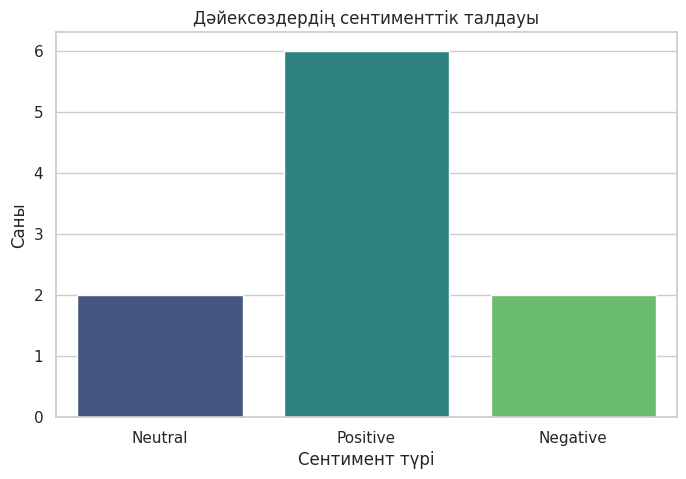

Ең позитивті дәйексөз:
“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”


In [20]:
# 1. Сентименттердің санын санау
sentiment_counts = df['sentiment_category'].value_counts()

# 2. График салу
plt.figure(figsize=(8, 5))

# TODO: sns.barplot немесе sns.countplot қолданып, 'sentiment_category' бағанасын визуализациялаңыз
# data параметріне df-ті беріңіз
# TODO
sns.countplot(x='sentiment_category', data=df, palette='viridis')

plt.title('Дәйексөздердің сентименттік талдауы')
plt.xlabel('Сентимент түрі')
plt.ylabel('Саны')
plt.show()

# Ең позитивті дәйексөзді шығару
print("Ең позитивті дәйексөз:")
# TODO: df деректерін сұрыптап (sort_values), ең жоғарғы polarity мәні бар жолды шығарыңыз
most_positive = df.sort_values(by='polarity')
print(most_positive['quote'].values[0])


## 7. Қорытынды сұрақтар (Markdown)

**Студенттің жауабы:**

1. Web Scraping жасау кезінде қандай қиындықтар туындауы мүмкін (мысалы, `status_code 403`)?
2. `TextBlob` кітапханасы сентиментті қалай анықтайды (ережеге негізделген бе әлде ML моделі ме)?
3. Егер сайтта "Келесі бет" (Next Page) батырмасы болса, барлық беттерді қалай жинауға болады? (Логикасын жазыңыз).


**Тапсырманы орындап болған соң, .ipynb файлын жүйеге жүктеңіз.**

1. page connot be found  , or might appear some issues from site , url can be wrong

2. TextBlob кітапханасы негізінен ережеге негізделген (lexicon-based) тәсілді қолданады.

Жұмыс істеу принципі: Оның ішінде алдын ала дайындалған сөздік (lexicon) бар. Бұл сөздікте әрбір сөзге "polarity" (жағымды/жағымсыз) және "subjectivity" (субъективтілік) ұпайлары берілген. Мысалы, "good" сөзіне оң мән, "bad" сөзіне теріс мән беріледі.

Талдау: Сөйлемдегі сын есімдер мен үстеулерді тауып, олардың сөздіктегі ұпайларын қосады. Сондай-ақ, "not" (теріске шығару) немесе "very" (күшейткіш) сияқты сөздердің әсерін ескеретін арнайы ережелерді қолданады.

ML нұсқасы: Айта кету керек, TextBlob-ты NaiveBayesAnalyzer арқылы Machine Learning (ML) моделімен де жұмыс істетуге болады (ол Movie Reviews корпусында жаттықтырылған), бірақ әдепкі бойынша (default) ол қарапайым ережелер мен сөздікті қолданады.

3.

    import requests
    from bs4 import BeautifulSoup
    import time

    base_url = "https://example.com"
    current_url = "/products?page=1"

    all_data = []

    while current_url:
        print(f"Scraping: {base_url + current_url}")
        
        # 1. Fetch the page
        response = requests.get(base_url + current_url)
        soup = BeautifulSoup(response.text, 'html.parser')

        # 2. Extract your data (e.g., product titles)
        items = soup.find_all('div', class_='product-item')
        for item in items:
            all_data.append(item.text.strip())

        # 3. Find the "Next" button
        # Note: You must inspect the site to find the correct class or text
        next_button = soup.find('a', string='Next')
        
        if next_button and next_button.get('href'):
            # Update current_url to the next page link
            current_url = next_button.get('href')
        
        # 4. Be polite! Wait 1-2 seconds between pages to avoid being blocked
        time.sleep(1)
    else:
        # No more "Next" button found, exit the loop
        current_url = None

print(f"Total items collected: {len(all_data)}")

In [22]:
import requests
from bs4 import BeautifulSoup
import time
from urllib.parse import urljoin # Import urljoin for robust URL construction

# Base URL of the website
base_url = "http://quotes.toscrape.com"
# Start with the full URL of the first page
current_page_url = "http://quotes.toscrape.com/page/1/"

all_data = []

while current_page_url: # Loop while there's a page URL to scrape
    print(f"Scraping: {current_page_url}") # Print the correct URL being scraped

    # 1. Fetch the page
    response = requests.get(current_page_url)
    response.raise_for_status() # Raise an exception for bad status codes (4xx or 5xx)
    soup = BeautifulSoup(response.text, 'html.parser')

    # 2. Extract your data
    quotes_on_page = soup.find_all('div', class_='quote')
    for q_html in quotes_on_page:

        text_content = q_html.find('span', class_='text').text
        author_name = q_html.find('small', class_='author').text
        all_data.append({'author': author_name, 'quote': text_content})
        all_data.append(q_html.text.strip())

    # 3. Find the "Next" button
    # The 'Next' button is typically inside an <a> tag within a <li class="next"> on quotes.toscrape.com
    next_li = soup.find('li', class_='next')
    if next_li:
        next_link_tag = next_li.find('a')
        if next_link_tag and next_link_tag.get('href'):
            # The href will be a relative path like '/page/2/'
            relative_next_page_path = next_link_tag.get('href')
            current_page_url = urljoin(base_url, relative_next_page_path) # Form the full URL for the next page safely
        else:
            current_page_url = None # No href found, end scraping
    else:
        current_page_url = None # No 'next' li element found, end scraping

    # 4. Be polite! Wait 1-2 seconds between pages to avoid being blocked
    if current_page_url: # Only sleep if there's a next page to fetch
        time.sleep(1)

print(f"Total items collected: {len(all_data)}")

Scraping: http://quotes.toscrape.com/page/1/
Scraping: http://quotes.toscrape.com/page/2/
Scraping: http://quotes.toscrape.com/page/3/
Scraping: http://quotes.toscrape.com/page/4/
Scraping: http://quotes.toscrape.com/page/5/
Scraping: http://quotes.toscrape.com/page/6/
Scraping: http://quotes.toscrape.com/page/7/
Scraping: http://quotes.toscrape.com/page/8/
Scraping: http://quotes.toscrape.com/page/9/
Scraping: http://quotes.toscrape.com/page/10/
Total items collected: 200


In [25]:
# Filter all_data to include only dictionaries
cleaned_all_data = [item for item in all_data if isinstance(item, dict)]

df = pd.DataFrame(data=cleaned_all_data)

In [26]:
# Сентиментті анықтайтын функция
def get_sentiment(text):
    # TODO: TextBlob объектісін құрыңыз (blob = TextBlob(text))
    blob =TextBlob(text)

    # TODO: blob.sentiment.polarity мәнін қайтарыңыз (return ...)
    return blob.sentiment.polarity

# Функцияны DataFrame-ге қолдану
# TODO: 'quote' бағанасына apply функциясы арқылы get_sentiment функциясын қолданыңыз
df['polarity'] = df['quote'].apply(get_sentiment)

# Сентимент категориясын анықтау (Positive, Negative, Neutral)
def categorize_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Категория бағанасын құру
df['sentiment_category'] = df['polarity'].apply(categorize_sentiment)

print("Сентимент талдауы бар деректер:")
display(df.head())

Сентимент талдауы бар деректер:


,author,quote,polarity,sentiment_category
0,Albert Einstein,“The world as we have created it is a process ...,0.000000,Neutral
1,J.K. Rowling,"“It is our choices, Harry, that show what we t...",0.300000,Positive
2,Albert Einstein,“There are only two ways to live your life. On...,0.003788,Positive
3,Jane Austen,"“The person, be it gentleman or lady, who has ...",-0.050000,Negative
4,Marilyn Monroe,"“Imperfection is beauty, madness is genius and...",-0.277778,Negative


/tmp/ipython-input-17924526.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_category', data=df, palette='viridis')


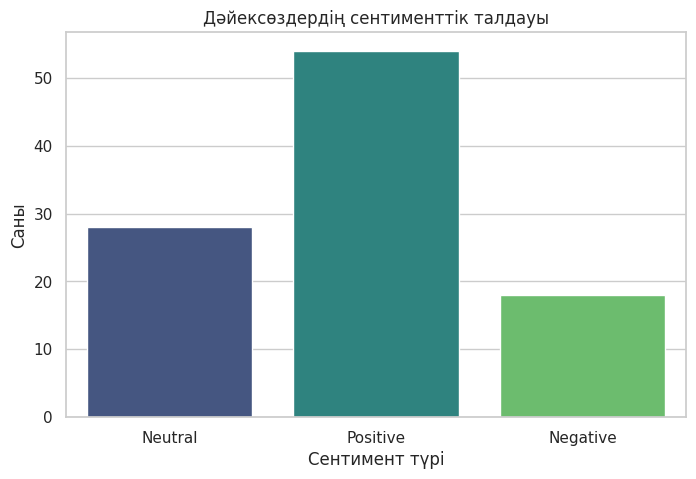

Ең позитивті дәйексөз:
“Some people never go crazy. What truly horrible lives they must lead.”


In [27]:
sentiment_counts = df['sentiment_category'].value_counts()
plt.figure(figsize=(8, 5))

sns.countplot(x='sentiment_category', data=df, palette='viridis')

plt.title('Дәйексөздердің сентименттік талдауы')
plt.xlabel('Сентимент түрі')
plt.ylabel('Саны')
plt.show()

print("Ең позитивті дәйексөз:")
most_positive = df.sort_values(by='polarity')
print(most_positive['quote'].values[0])